In [3]:
!pip install matplotlib
#!sudo apt install python3-matplotlib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    For more information visit http://rptl.io/venv

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


In [1]:
import os
import FinanceDataReader as fdr
import numpy as np
import matplotlib.pyplot as plt
print(f'CWD = {os.getcwd()}')
print(os.name)
print(f'PYTHONPATH-{os.getenv("PYTHONPATH")}')

CWD = /home/swhors/jupyter-workspace/finance
posix
PYTHONPATH-/home/swhors/jupyter-workspace/venv/lib/python3.11/site-packages


In [2]:
print(f'{fdr.__version__}')

0.9.94


In [ ]:
stocks = fdr.StockListing('KOSPI-DESC') # KOSPI: 5,897 종목
print(stocks)

In [67]:
stocks = fdr.StockListing('NASDAQ') # 나스닥 (NASDAQ): 4천+ 종목
print(stocks)

100%|██████████| 3646/3646 [00:04<00:00, 902.32it/s] 


     Symbol                                          Name IndustryCode  \
0      AAPL                                     Apple Inc     57106020   
1      NVDA                                   NVIDIA Corp     57101010   
2      MSFT                                Microsoft Corp     57201020   
3      AMZN                                Amazon.com Inc     53402010   
4      META                            Meta Platforms Inc     57201030   
...     ...                                           ...          ...   
3641  METCZ  Ramaco Resources 8 375 Senior Notes due 2029     51201020   
3642  BEAGR                 Bold Eagle Acquisition Rights     55601010   
3643  GSRTR                    GSR III Acquisition Rights     55601010   
3644  TAVIR                      Tavia Acquisition Rights     55601010   
3645   ONEG                     OneConstruction Group Ltd     52201020   

        Industry  
0     전화 및 소형 장치  
1            반도체  
2          소프트웨어  
3            백화점  
4        온라인 서비스

In [72]:
aapl = fdr.DataReader('NVDA', '2023-01-01', '2025-12-30')
print(f'aapl={aapl}')

aapl=                  Open        High         Low       Close     Volume  \
2023-01-03   14.851000   14.996000   14.096000   14.315000  401277000   
2023-01-04   14.567000   14.853000   14.241000   14.749000  431324000   
2023-01-05   14.491000   14.564000   14.148000   14.265000  389168000   
2023-01-06   14.474000   15.010000   14.034000   14.859000  405044000   
2023-01-09   15.284000   16.056000   15.141000   15.628000  504231000   
...                ...         ...         ...         ...        ...   
2024-12-24  140.000000  141.899994  138.649994  140.220001  105157000   
2024-12-26  139.699997  140.850006  137.729996  139.929993  116205600   
2024-12-27  138.550003  139.020004  134.710007  137.009995  170582600   
2024-12-30  134.830002  140.270004  134.020004  137.490005  167734700   
2024-12-31  138.029999  138.070007  133.830002  134.289993  155659200   

             Adj Close  
2023-01-03   14.304595  
2023-01-04   14.738280  
2023-01-05   14.254632  
2023-01-06   14.84

In [103]:
def draw_graph(title, np_data):
    datas = np_data['Close']
    volumes = np_data['Volume']
    plt.plot(np_data.index, [d for d in datas], label='value', marker='.', markerfacecolor='g')
    plt.plot(np_data.index, [v/1000 for v in volumes], label='volume', marker='.', markerfacecolor='b')
    plt.xlabel("date")
    plt.title(title)
    plt.show()

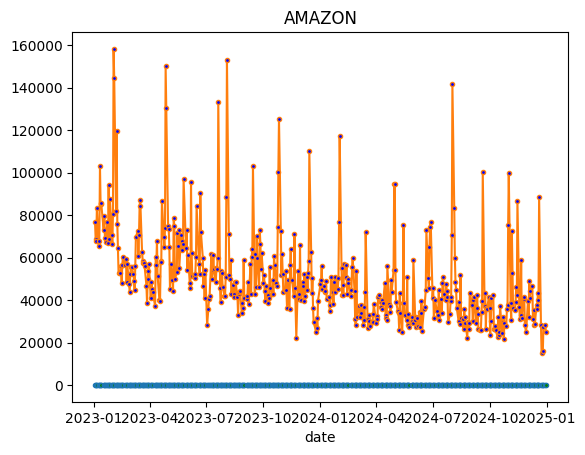

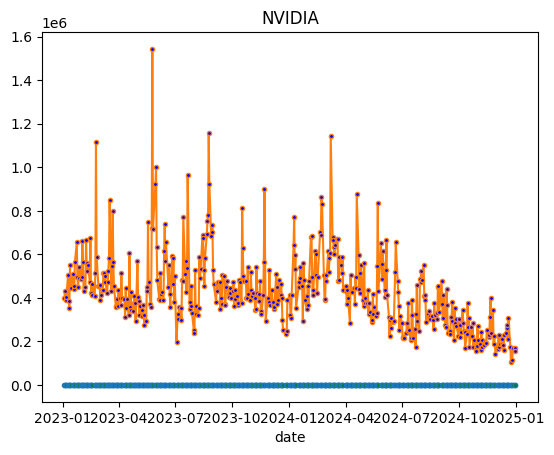

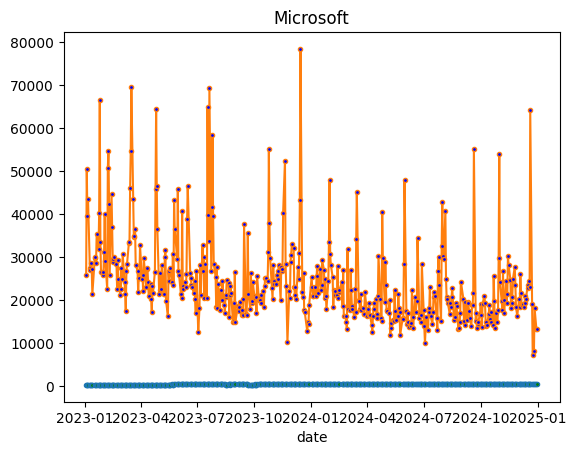

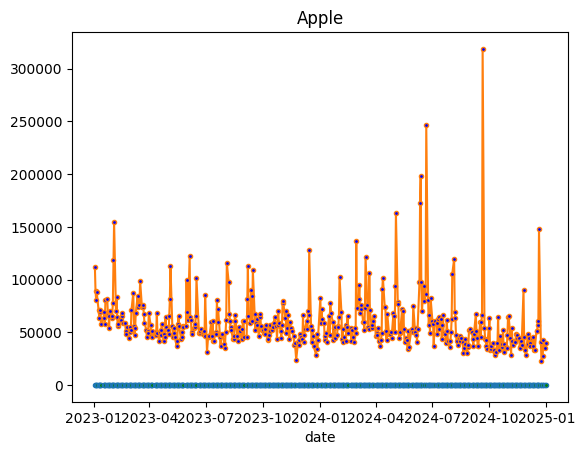

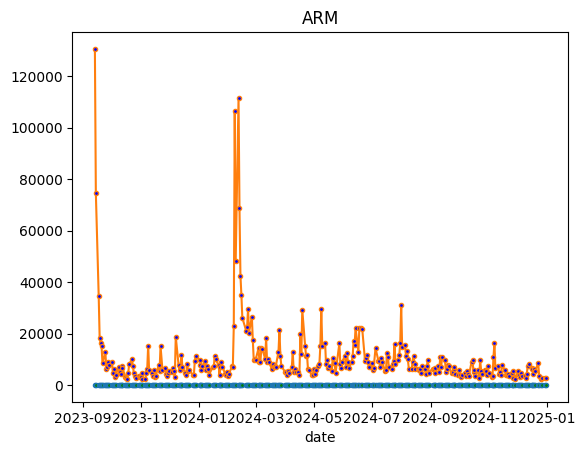

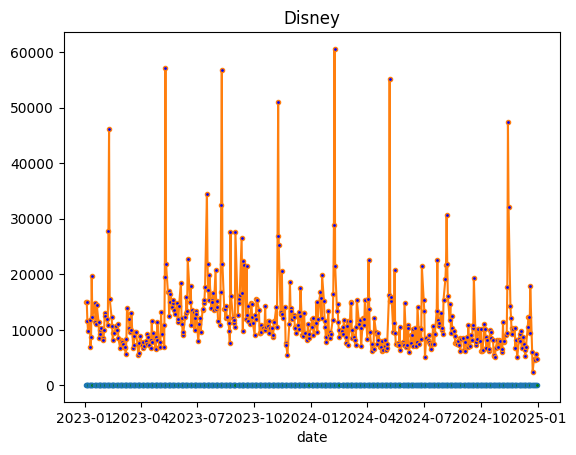

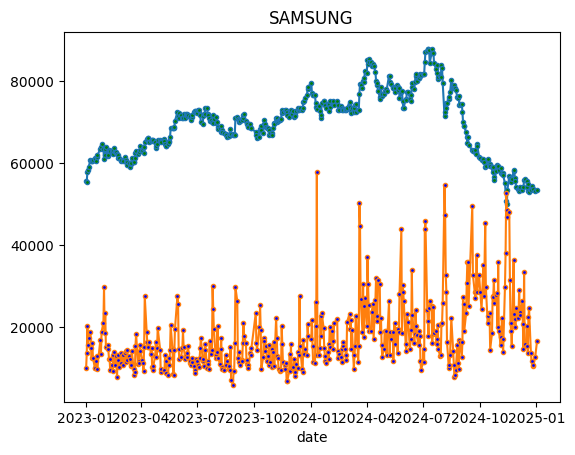

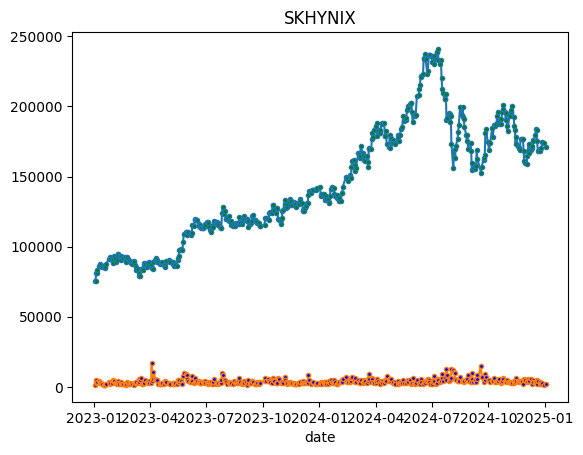

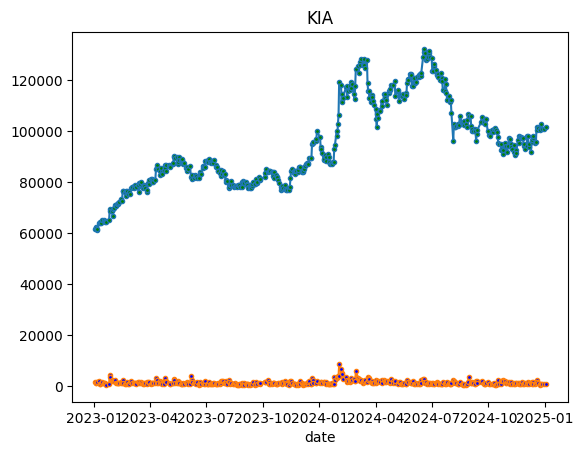

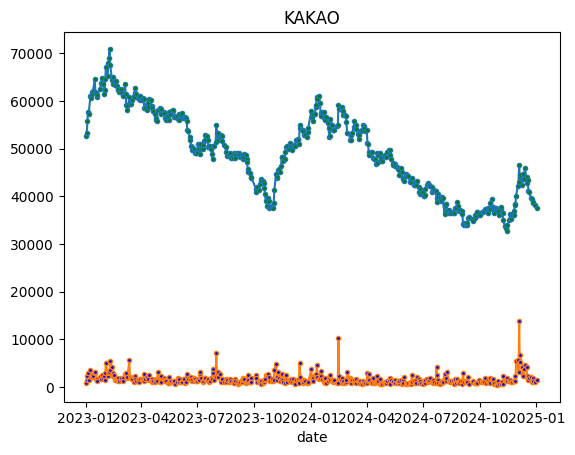

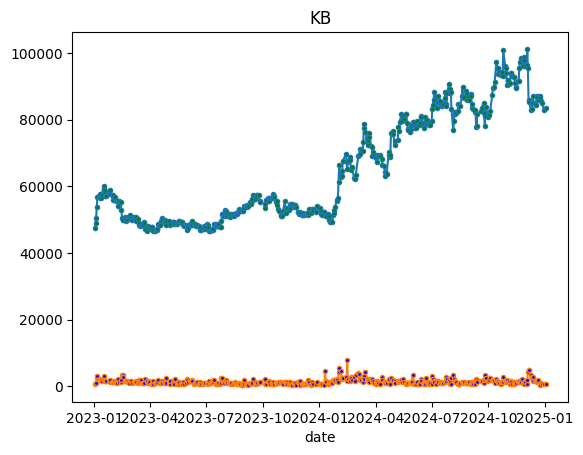

In [104]:
KV = {"AMAZON":"AMZN", "NVIDIA":"NVDA", "Microsoft":"MSFT", "Apple":"AAPL", "ARM":"ARM", "Disney":"DIS", "SAMSUNG":"005930", "SKHYNIX":"000660", "KIA":"000270", "KAKAO":"035720", "KB":"105560"}
for key in KV:
    df = fdr.DataReader(KV[key], '2023-01-01', '2025-12-30')
    draw_graph(key, df)